C:\Users\sebas\AppData\Local\Temp/ipykernel_19092/3605301325.py:14: RuntimeWarning: overflow encountered in exp
  integral, _ = quad(lambda x: (x**4 * np.exp(x)) / (np.exp(x) - 1)**2, 0, Theta_D/T)
C:\Users\sebas\AppData\Local\Temp/ipykernel_19092/3605301325.py:14: RuntimeWarning: invalid value encountered in scalar divide
  integral, _ = quad(lambda x: (x**4 * np.exp(x)) / (np.exp(x) - 1)**2, 0, Theta_D/T)
C:\Users\sebas\AppData\Local\Temp/ipykernel_19092/3605301325.py:14: RuntimeWarning: overflow encountered in scalar power
  integral, _ = quad(lambda x: (x**4 * np.exp(x)) / (np.exp(x) - 1)**2, 0, Theta_D/T)
C:\Users\sebas\AppData\Local\Temp/ipykernel_19092/3605301325.py:14: RuntimeWarning: overflow encountered in scalar multiply
  integral, _ = quad(lambda x: (x**4 * np.exp(x)) / (np.exp(x) - 1)**2, 0, Theta_D/T)
C:\Users\sebas\AppData\Local\Temp/ipykernel_19092/3605301325.py:14: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolera

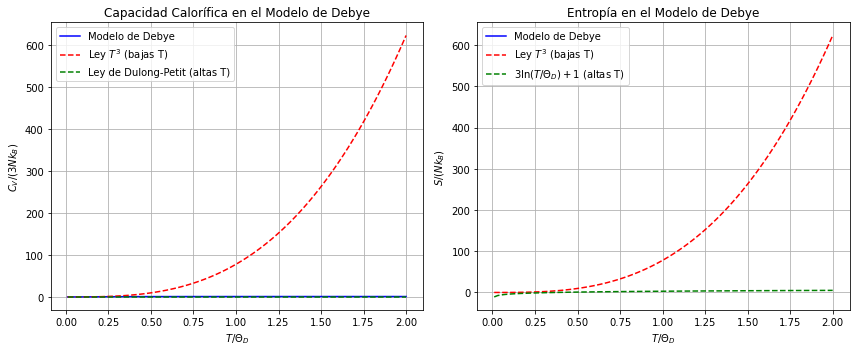

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Constantes
N = 1  # Número de partículas (normalizado a 1)
kB = 1  # Constante de Boltzmann (normalizada a 1)
Theta_D = 1  # Temperatura de Debye (normalizada a 1)

# Función para calcular C_V en el modelo de Debye
def cv_debye(T):
    if T == 0:
        return 0
    integral, _ = quad(lambda x: (x**4 * np.exp(x)) / (np.exp(x) - 1)**2, 0, Theta_D/T)
    return 9 * N * kB * (T/Theta_D)**3 * integral

# Función para calcular la entropía S (integral de C_V / T)
def entropy_debye(T):
    if T == 0:
        return 0
    # Usamos quad para integrar C_V(T')/T' desde 0 a T
    integral, _ = quad(lambda t: cv_debye(t)/t if t > 0 else 0, 0, T)
    return integral

# Valores de temperatura normalizada (T/Theta_D)
T_values = np.linspace(0.01, 2, 100)  # Desde cerca de 0 hasta 2*Theta_D

# Calculamos C_V y S para cada T
C_V_values = [cv_debye(T) / (3 * N * kB) for T in T_values]  # Normalizado a 3NkB
S_values = [entropy_debye(T) / (N * kB) for T in T_values]    # Normalizado a NkB

# Límites teóricos
# Bajas T: C_V ≈ (12*pi^4/5) * (T/Theta_D)^3 (normalizado a 3NkB)
C_V_low_T = (12 * np.pi**4 / 5) * (T_values**3) / (3 * Theta_D**3)
# Altas T: C_V ≈ 3NkB (normalizado a 1)
C_V_high_T = np.ones_like(T_values)

# Bajas T: S ≈ (4*pi^4/5) * (T/Theta_D)^3 (normalizado a NkB)
S_low_T = (4 * np.pi**4 / 5) * (T_values**3) / (Theta_D**3)
# Altas T: S ≈ 3NkB * [ln(T/Theta_D) + 1] (normalizado a 1)
S_high_T = 3 * (np.log(T_values) + 1)

# Gráficas
plt.figure(figsize=(12, 5))

# Gráfica 1: Capacidad Calorífica C_V
plt.subplot(1, 2, 1)
plt.plot(T_values, C_V_values, 'b-', label='Modelo de Debye')
plt.plot(T_values, C_V_low_T, 'r--', label='Ley $T^3$ (bajas T)')
plt.plot(T_values, C_V_high_T, 'g--', label='Ley de Dulong-Petit (altas T)')
plt.xlabel('$T / \Theta_D$')
plt.ylabel('$C_V / (3Nk_B)$')
plt.title('Capacidad Calorífica en el Modelo de Debye')
plt.legend()
plt.grid(True)

# Gráfica 2: Entropía S
plt.subplot(1, 2, 2)
plt.plot(T_values, S_values, 'b-', label='Modelo de Debye')
plt.plot(T_values, S_low_T, 'r--', label='Ley $T^3$ (bajas T)')
plt.plot(T_values, S_high_T, 'g--', label='$3 \ln(T/\Theta_D) + 1$ (altas T)')
plt.xlabel('$T / \Theta_D$')
plt.ylabel('$S / (Nk_B)$')
plt.title('Entropía en el Modelo de Debye')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()